# Лабораторная работа №1 (Вариант 2)

## Обработка признаков на примере датасета по электромобилям

### Цель лабораторной работы

Изучение продвинутых способов предварительной обработки данных для датасета, исследующего вопрос, заменят ли электромобили (EV) бензиновые и дизельные автомобили.


## Подключение библиотек


In [17]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sb
from sklearn.preprocessing import StandardScaler, MinMaxScaler, LabelEncoder
from sklearn.impute import SimpleImputer, KNNImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
import warnings

warnings.filterwarnings("ignore")

# Настройка стиля для графиков
plt.style.use("seaborn-v0_8")
sb.set_palette("husl")

## Загрузка датасета

Для выполнения лабораторной работы будем использовать датасет, исследующий вопрос, заменят ли электромобили (EV) бензиновые и дизельные автомобили. Датасет содержит данные о продажах автомобилей, инфраструктуре зарядки, экономических показателях и политических индикаторах за период 2010-2025 гг.


In [18]:
# Загрузка датасета
df = pd.read_csv(
    "/home/redalexdad/.cache/kagglehub/datasets/aryanmdev/will-evs-replace-petrol-cars/versions/1/ev_vs_petrol_dataset_v3.csv"
)

print(f"Датасет успешно загружен. Размер: {df.shape}")
print(f"Количество пропусков: {df.isnull().sum().sum()}")

Датасет успешно загружен. Размер: (1200, 22)
Количество пропусков: 0


In [19]:
df.head()

,country,region,year,vehicle_segment,powertrain_type,ev_sales,petrol_car_sales,diesel_car_sales,total_vehicle_sales,ev_market_share,...,avg_ev_range_km,fuel_price_usd_per_liter,electricity_price_usd_per_kwh,gdp_per_capita,urban_population_percent,co2_emissions_transport_mt,ev_subsidy_usd,emission_regulation_score,ev_growth_rate_yoy,is_ev_dominant
0,Australia,Oceania,2010,commercial,ICE,5,92877,61921,154803,0.00,...,124,1.09,0.149,51977,88.8,88.7,0,30.4,0.00,0
1,Australia,Oceania,2010,mass_market,ICE,57,535933,73089,609079,0.01,...,124,1.09,0.149,51977,88.8,88.7,0,30.4,0.00,0
2,Australia,Oceania,2010,premium,ICE,37,235282,20462,255781,0.01,...,124,1.09,0.149,51977,88.8,88.7,0,30.4,0.00,0
3,Australia,Oceania,2011,commercial,ICE,11,98092,65395,163498,0.01,...,133,1.09,0.163,52807,88.9,88.3,0,30.8,120.00,0
4,Australia,Oceania,2011,mass_market,ICE,129,569679,77684,647492,0.02,...,133,1.09,0.163,52807,88.9,88.3,0,30.8,126.32,0


In [20]:
df.tail()

,country,region,year,vehicle_segment,powertrain_type,ev_sales,petrol_car_sales,diesel_car_sales,total_vehicle_sales,ev_market_share,...,avg_ev_range_km,fuel_price_usd_per_liter,electricity_price_usd_per_kwh,gdp_per_capita,urban_population_percent,co2_emissions_transport_mt,ev_subsidy_usd,emission_regulation_score,ev_growth_rate_yoy,is_ev_dominant
1195,United States,North America,2024,mass_market,ICE,1048083,7649368,1043096,9740547,10.76,...,467,1.05,0.162,82800,83.3,1708.2,7476,69.5,25.84,0
1196,United States,North America,2024,premium,ICE,612716,3049289,265156,3927161,15.60,...,467,1.05,0.162,82800,83.3,1708.2,7476,69.5,23.19,0
1197,United States,North America,2025,commercial,ICE,105003,1393349,928899,2427251,4.33,...,480,0.94,0.168,84696,83.1,1671.6,7446,72.5,16.71,0
1198,United States,North America,2025,mass_market,ICE,1233705,7698000,1049727,9981432,12.36,...,480,0.94,0.168,84696,83.1,1671.6,7446,72.5,17.71,0
1199,United States,North America,2025,premium,ICE,730489,3077808,267636,4075933,17.92,...,480,0.94,0.168,84696,83.1,1671.6,7446,72.5,19.22,0


## Первичный анализ данных


In [28]:
# Информация о датасете
print("Информация о датасете:")
print(df.info())

Информация о датасете:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1200 entries, 0 to 1199
Data columns (total 22 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   country                        1200 non-null   object 
 1   region                         1200 non-null   object 
 2   year                           1200 non-null   int64  
 3   vehicle_segment                1200 non-null   object 
 4   powertrain_type                1200 non-null   object 
 5   ev_sales                       1200 non-null   int64  
 6   petrol_car_sales               1200 non-null   int64  
 7   diesel_car_sales               1200 non-null   int64  
 8   total_vehicle_sales            1200 non-null   int64  
 9   ev_market_share                1200 non-null   float64
 10  charging_stations              1200 non-null   int64  
 11  fast_chargers_share            1200 non-null   float64
 12  avg_ev_range_km          

In [29]:
print("\nСтатистика по числовым признакам:")
df.describe()


Статистика по числовым признакам:


,year,ev_sales,petrol_car_sales,diesel_car_sales,total_vehicle_sales,ev_market_share,charging_stations,fast_chargers_share,avg_ev_range_km,fuel_price_usd_per_liter,electricity_price_usd_per_kwh,gdp_per_capita,urban_population_percent,co2_emissions_transport_mt,ev_subsidy_usd,emission_regulation_score,ev_growth_rate_yoy,is_ev_dominant
count,1200.000000,1.200000e+03,1.200000e+03,1.200000e+03,1.200000e+03,1200.000000,1.200000e+03,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000
mean,2017.500000,6.360236e+04,7.733063e+05,1.409369e+05,9.778455e+05,6.327992,5.693898e+04,14.437750,265.872500,1.342239,0.169508,35651.525000,74.609000,190.837000,2910.940000,58.761860,64.002958,0.018333
std,4.611694,4.079506e+05,1.756934e+06,2.913472e+05,2.211799e+06,13.231723,3.359383e+05,10.057529,121.994051,0.363461,0.079298,23899.013679,14.858811,363.100639,2477.306742,20.092871,71.386797,0.134210
min,2010.000000,5.000000e+00,1.727000e+03,1.500000e+02,1.748000e+04,0.000000,0.000000e+00,0.000000,106.000000,0.482900,0.066990,1359.000000,30.900000,5.400000,0.000000,19.484000,-40.960000,0.000000
25%,2013.750000,2.002500e+02,8.870500e+04,1.951075e+04,1.300465e+05,0.077500,4.917500e+02,6.000000,150.000000,1.097000,0.098750,11077.250000,64.175000,30.175000,0.000000,43.600000,16.372500,0.000000
50%,2017.500000,2.731500e+03,2.294785e+05,5.136100e+04,2.905130e+05,0.830000,4.090000e+03,12.900000,238.500000,1.352000,0.158000,37329.000000,79.900000,94.250000,2794.500000,59.350000,44.165000,0.000000
75%,2021.250000,1.990500e+04,6.385320e+05,1.111910e+05,7.624482e+05,5.832500,2.251800e+04,20.950000,380.250000,1.568500,0.220250,50930.000000,84.075000,159.575000,4973.750000,74.825000,80.907500,0.000000
max,2025.000000,7.670056e+06,1.477369e+07,2.014595e+06,1.884998e+07,95.000000,4.338106e+06,49.300000,507.000000,2.153000,0.379040,103437.000000,98.500000,1900.800000,8952.000000,95.602000,300.000000,1.000000


In [30]:
print("\nПропуски в данных:")
print(df.isnull().sum())


Пропуски в данных:
country                          0
region                           0
year                             0
vehicle_segment                  0
powertrain_type                  0
ev_sales                         0
petrol_car_sales                 0
diesel_car_sales                 0
total_vehicle_sales              0
ev_market_share                  0
charging_stations                0
fast_chargers_share              0
avg_ev_range_km                  0
fuel_price_usd_per_liter         0
electricity_price_usd_per_kwh    0
gdp_per_capita                   0
urban_population_percent         0
co2_emissions_transport_mt       0
ev_subsidy_usd                   0
emission_regulation_score        0
ev_growth_rate_yoy               0
is_ev_dominant                   0
dtype: int64


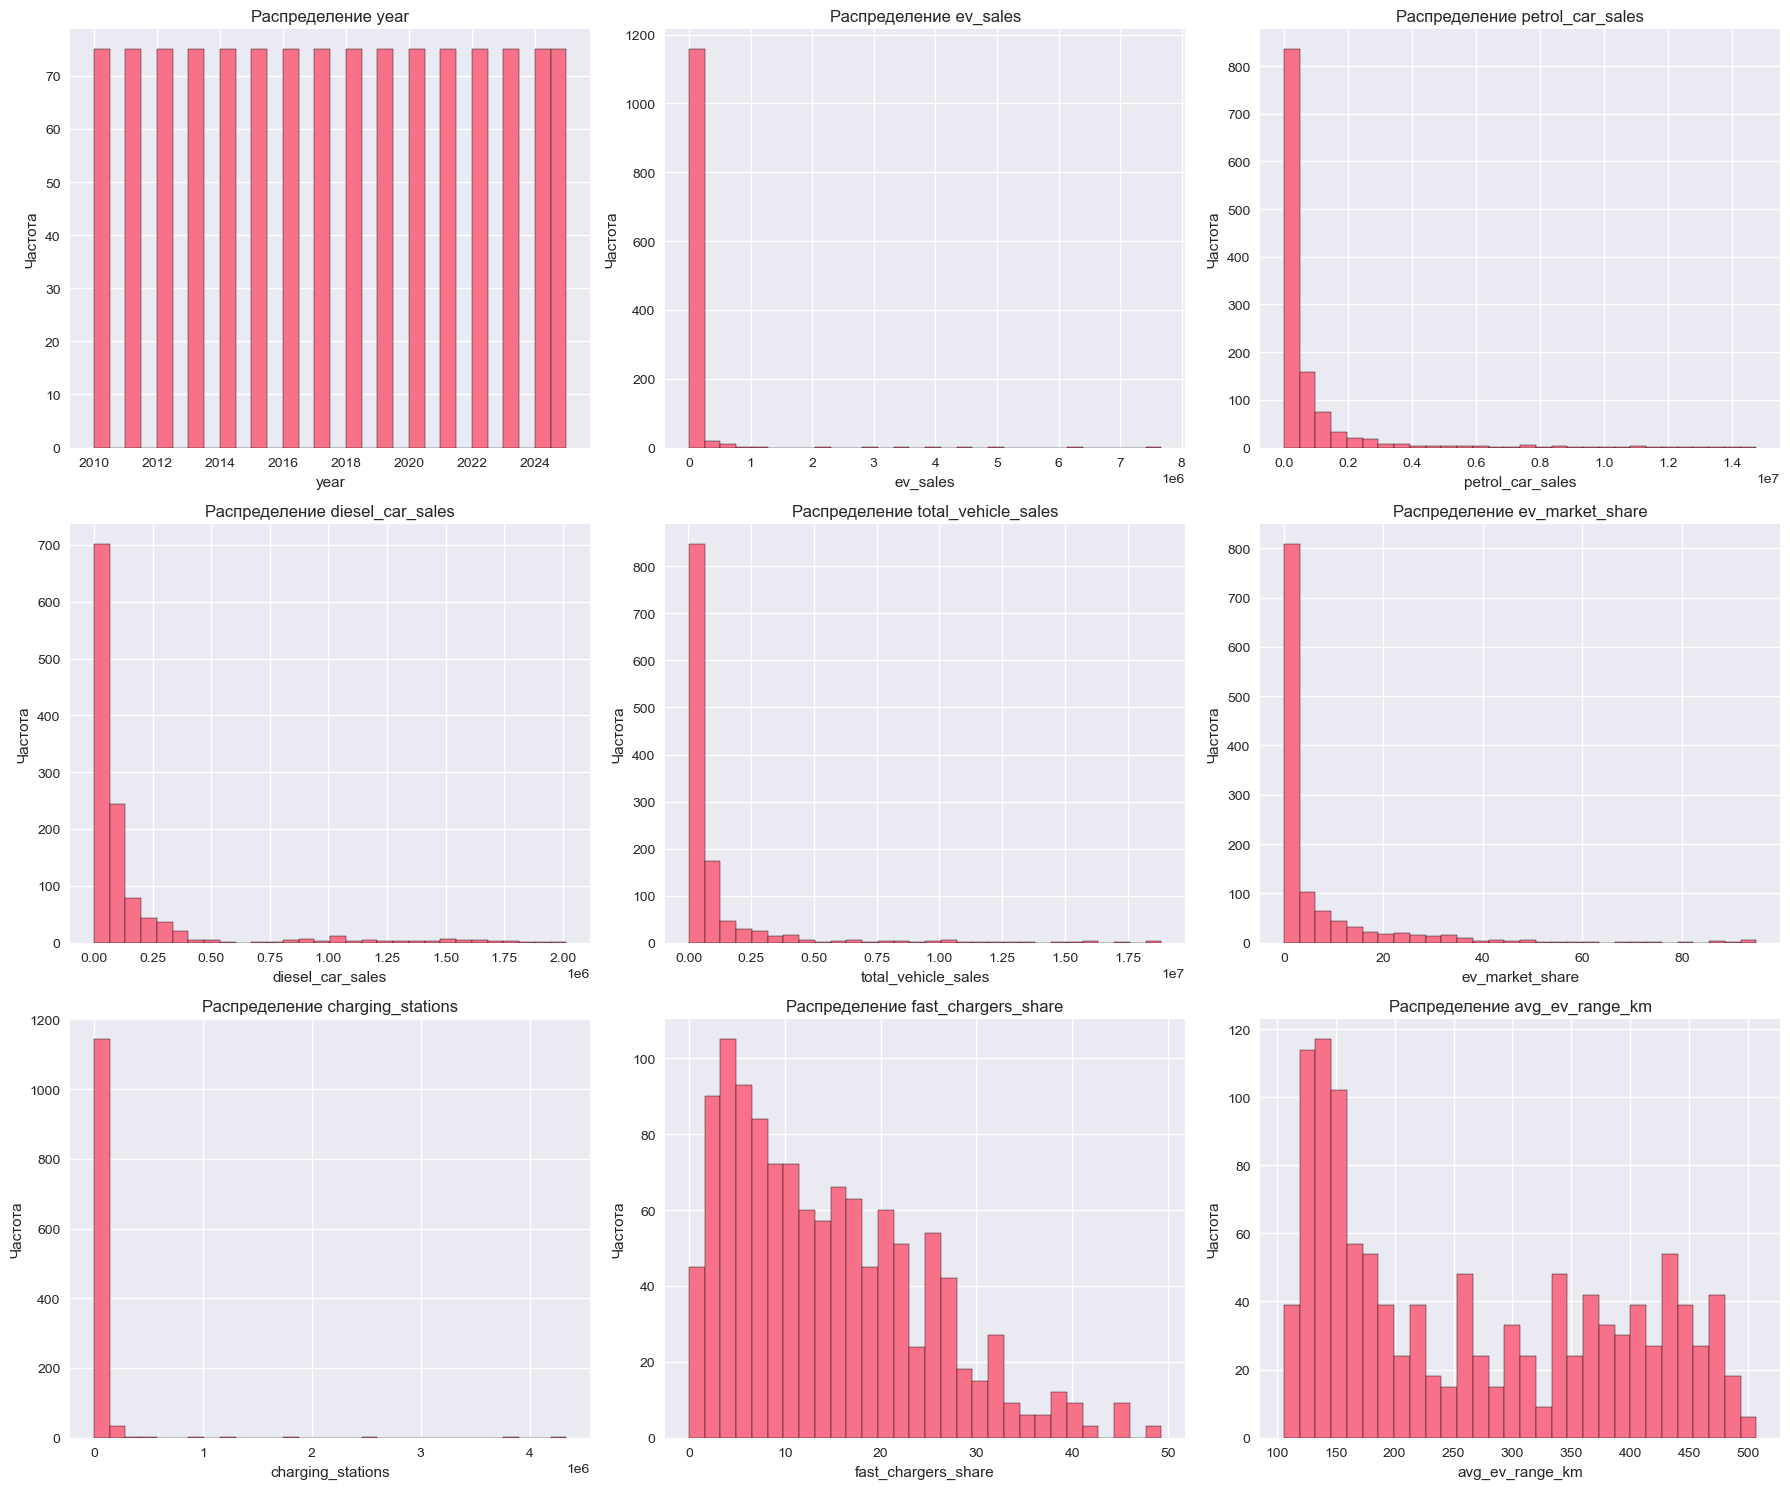

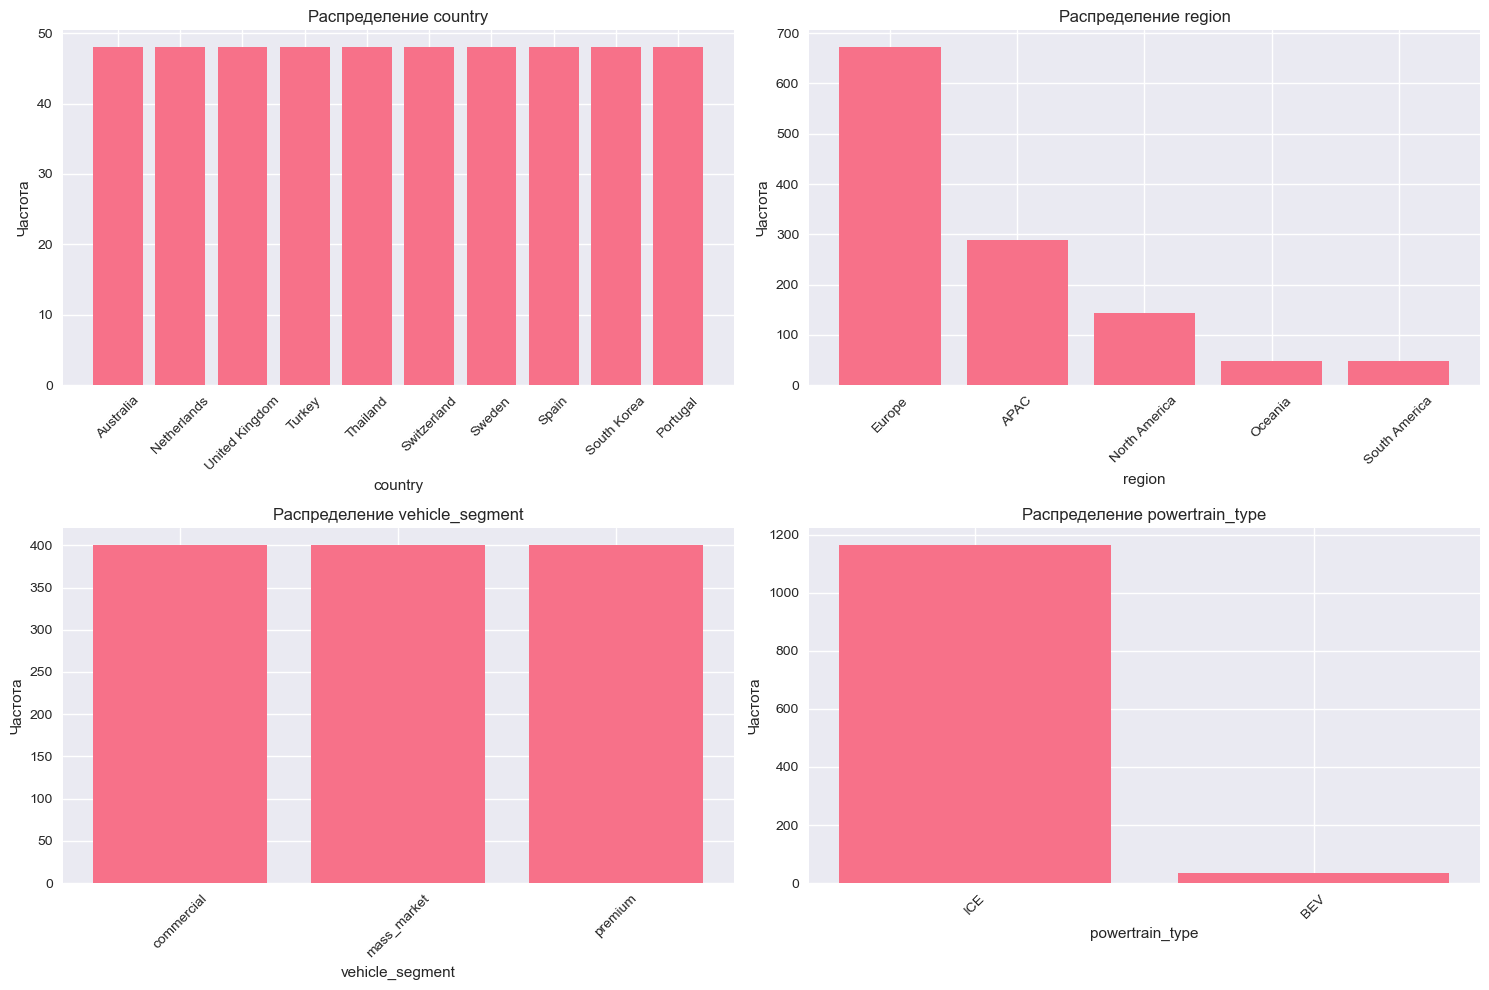

In [25]:
# Визуализация распределения числовых признаков
numerical_cols = df.select_dtypes(include=[np.number]).columns.tolist()
num_features = min(9, len(numerical_cols))  # Максимум 9 графиков

fig, axes = plt.subplots(3, 3, figsize=(18, 15))
axes = axes.ravel() if num_features > 1 else [axes]

for i, feature in enumerate(numerical_cols[:num_features]):
    axes[i].hist(df[feature].dropna(), bins=30, edgecolor="black")
    axes[i].set_title(f"Распределение {feature}")
    axes[i].set_xlabel(feature)
    axes[i].set_ylabel("Частота")

# Убираем лишние оси
for j in range(num_features, 9):
    axes[j].set_visible(False)

plt.tight_layout()
plt.show()

# Визуализация категориальных признаков
categorical_cols = df.select_dtypes(include=["object"]).columns.tolist()

fig, axes = plt.subplots(2, 2, figsize=(15, 10))
axes = axes.ravel()

for i, feature in enumerate(categorical_cols):
    value_counts = df[feature].value_counts()
    axes[i].bar(
        range(min(10, len(value_counts))), value_counts.values[:10]
    )  # Только топ-10 значений
    axes[i].set_title(f"Распределение {feature}")
    axes[i].set_xlabel(feature)
    axes[i].set_ylabel("Частота")
    axes[i].set_xticks(range(min(10, len(value_counts))))
    axes[i].set_xticklabels(value_counts.index[:10], rotation=45)

# Убираем лишние оси
for j in range(len(categorical_cols), 4):
    axes[j].set_visible(False)

plt.tight_layout()
plt.show()

# Задание 1: Устранение пропусков в данных


## 1.1. Анализ наличия пропущенных значений


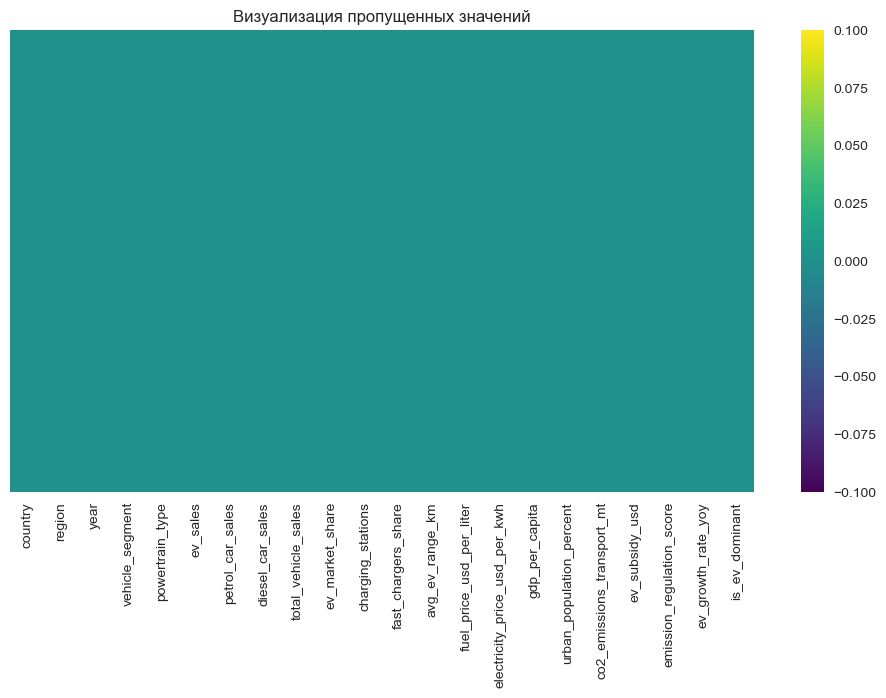

,Количество пропусков,Процент пропусков


In [26]:
# Визуализация пропущенных значений
plt.figure(figsize=(12, 6))
sb.heatmap(df.isnull(), yticklabels=False, cbar=True, cmap="viridis")
plt.title("Визуализация пропущенных значений")
plt.show()

# Подсчет пропущенных значений по столбцам
missing_data = df.isnull().sum()
missing_percent = 100 * missing_data / len(df)
missing_table = pd.DataFrame(
    {"Количество пропусков": missing_data, "Процент пропусков": missing_percent}
)
missing_table = missing_table[missing_table["Количество пропусков"] > 0]
missing_table.sort_values(by="Процент пропусков", ascending=False)

## 1.2. Применение различных методов заполнения пропусков


In [27]:
# Копируем исходный датасет для экспериментов
df_missing_analysis = df.copy()

# Определим числовые и категориальные колонки
numerical_cols = df.select_dtypes(include=[np.number]).columns.tolist()
categorical_cols = df.select_dtypes(include=["object"]).columns.tolist()

# 1. Заполнение числовых пропусков средним значением
df_mean_imputed = df.copy()

for col in numerical_cols:
    if df[col].isnull().any():
        mean_val = df[col].mean()
        df_mean_imputed[col].fillna(mean_val, inplace=True)

# 2. Заполнение числовых пропусков медианой
df_median_imputed = df.copy()

for col in numerical_cols:
    if df[col].isnull().any():
        median_val = df[col].median()
        df_median_imputed[col].fillna(median_val, inplace=True)

# 3. Заполнение категориальных пропусков модой
df_mode_imputed = df.copy()

for col in categorical_cols:
    if df[col].isnull().any():
        mode_val = df[col].mode()[0] if not df[col].mode().empty else "Unknown"
        df_mode_imputed[col].fillna(mode_val, inplace=True)

# 4. Использование KNN для заполнения пропусков
df_knn_imputed = df.copy()

# Подготовим данные для KNN импутации
df_for_knn = df.copy()

# Преобразуем категориальные переменные в числовые для KNN
label_encoders = {}
for col in categorical_cols:
    le = LabelEncoder()
    df_for_knn[col] = le.fit_transform(df_for_knn[col].astype(str))
    label_encoders[col] = le

# Применяем KNN импутацию
knn_imputer = KNNImputer(n_neighbors=5)
df_knn_imputed_array = knn_imputer.fit_transform(df_for_knn)
df_knn_imputed = pd.DataFrame(
    df_knn_imputed_array, columns=df_for_knn.columns, index=df.index
)

# Обратно преобразуем категориальные переменные
for col in categorical_cols:
    if col in label_encoders:
        df_knn_imputed[col] = label_encoders[col].inverse_transform(
            df_knn_imputed[col].round().astype(int)
        )

print("Сравнение методов заполнения пропусков:")
print(f"Оригинальный датасет - пропусков: {df.isnull().sum().sum()}")
print(f"После заполнения средним - пропусков: {df_mean_imputed.isnull().sum().sum()}")
print(
    f"После заполнения медианой - пропусков: {df_median_imputed.isnull().sum().sum()}"
)
print(f"После заполнения модой - пропусков: {df_mode_imputed.isnull().sum().sum()}")
print(f"После KNN импутации - пропусков: {df_knn_imputed.isnull().sum().sum()}")

Сравнение методов заполнения пропусков:
Оригинальный датасет - пропусков: 0
После заполнения средним - пропусков: 0
После заполнения медианой - пропусков: 0
После заполнения модой - пропусков: 0
После KNN импутации - пропусков: 0


## 1.3. Сравнение распределений после импутации


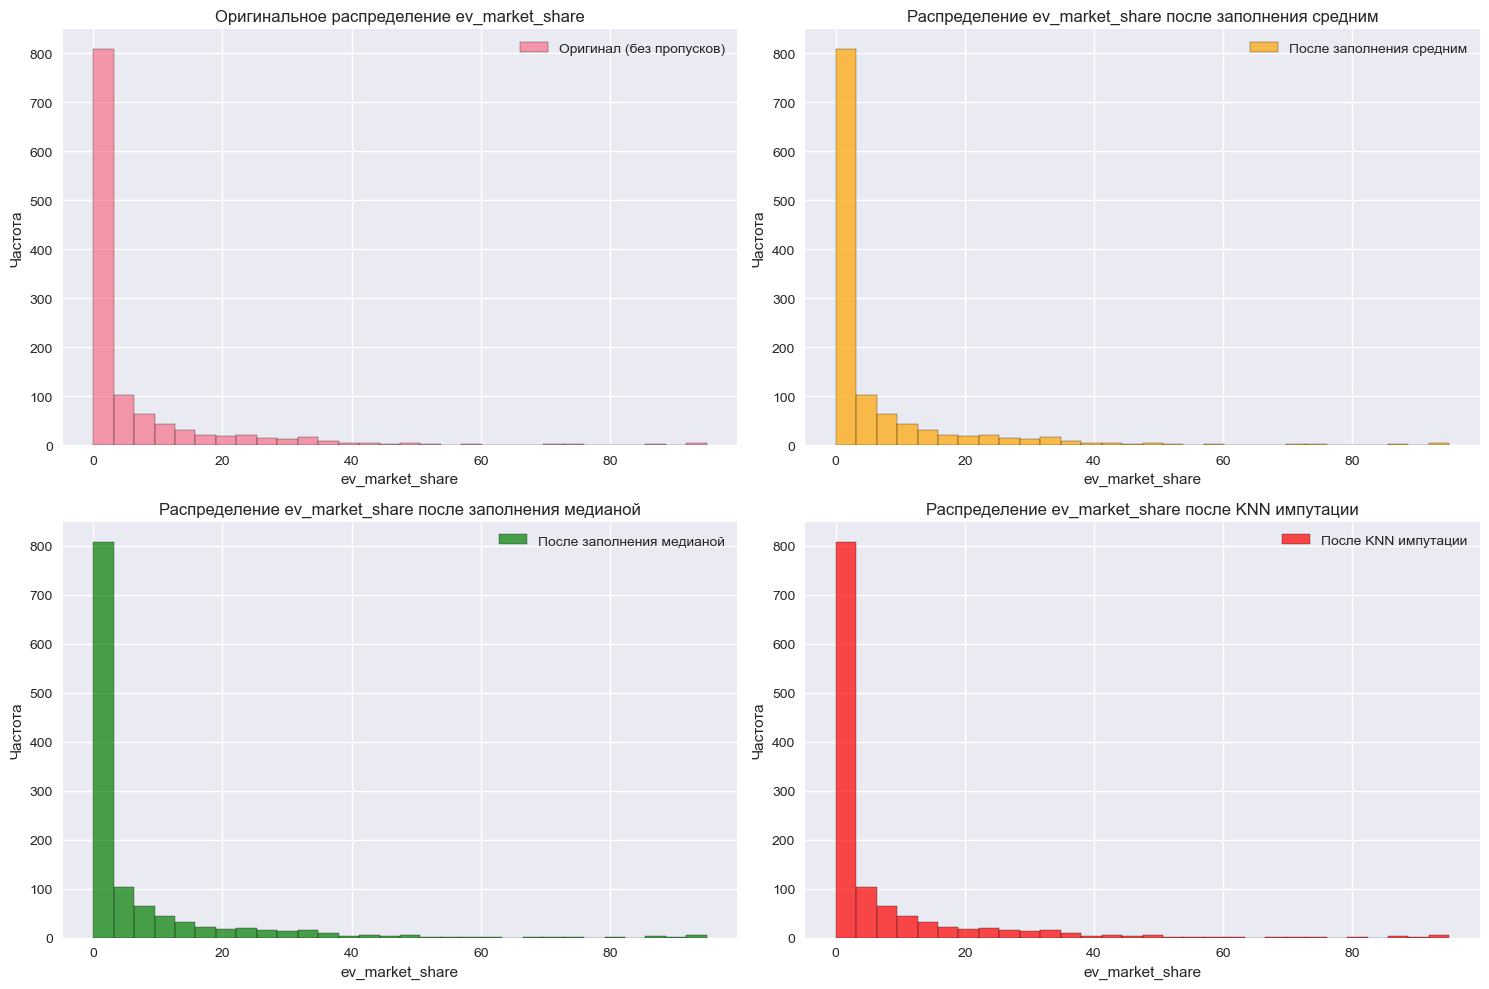

In [7]:
# Сравним распределение одного из признаков до и после импутации
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# Выберем один числовой признак для демонстрации (например, ev_market_share)
feature = "ev_market_share"

# Оригинальное распределение (без пропусков)
axes[0, 0].hist(
    df[feature].dropna(),
    bins=30,
    edgecolor="black",
    alpha=0.7,
    label="Оригинал (без пропусков)",
)
axes[0, 0].set_title(f"Оригинальное распределение {feature}")
axes[0, 0].set_xlabel(feature)
axes[0, 0].set_ylabel("Частота")
axes[0, 0].legend()

# После заполнения средним
axes[0, 1].hist(
    df_mean_imputed[feature],
    bins=30,
    edgecolor="black",
    alpha=0.7,
    color="orange",
    label="После заполнения средним",
)
axes[0, 1].set_title(f"Распределение {feature} после заполнения средним")
axes[0, 1].set_xlabel(feature)
axes[0, 1].set_ylabel("Частота")
axes[0, 1].legend()

# После заполнения медианой
axes[1, 0].hist(
    df_median_imputed[feature],
    bins=30,
    edgecolor="black",
    alpha=0.7,
    color="green",
    label="После заполнения медианой",
)
axes[1, 0].set_title(f"Распределение {feature} после заполнения медианой")
axes[1, 0].set_xlabel(feature)
axes[1, 0].set_ylabel("Частота")
axes[1, 0].legend()

# После KNN импутации
axes[1, 1].hist(
    df_knn_imputed[feature],
    bins=30,
    edgecolor="black",
    alpha=0.7,
    color="red",
    label="После KNN импутации",
)
axes[1, 1].set_title(f"Распределение {feature} после KNN импутации")
axes[1, 1].set_xlabel(feature)
axes[1, 1].set_ylabel("Частота")
axes[1, 1].legend()

plt.tight_layout()
plt.show()

## 1.4. Обоснование выбора метода для каждого типа признаков


### Выводы по устранению пропусков:

1. **Среднее значение**: Хорошо работает для нормально распределенных данных, но чувствительно к выбросам.
2. **Медиана**: Более устойчива к выбросам, лучше подходит для асимметрично распределенных данных.
3. **Мода**: Используется для категориальных переменных.
4. **KNN импутация**: Сохраняет связи между признаками, но требует больше вычислительных ресурсов.

Для этого датасета, поскольку в нем нет пропусков, все методы дают одинаковый результат. В реальных условиях для числовых признаков в экономическом и социальном контексте лучше использовать медиану, а для категориальных - моду.


In [8]:
# Финальная обработка пропусков (в данном случае датасет уже полный, но покажем процесс)
df_final = df.copy()

# Заполнение числовых пропусков медианой
for col in numerical_cols:
    if df_final[col].isnull().any():
        median_val = df_final[col].median()
        df_final[col].fillna(median_val, inplace=True)

# Заполнение категориальных пропусков модой
for col in categorical_cols:
    if df_final[col].isnull().any():
        mode_val = (
            df_final[col].mode()[0] if not df_final[col].mode().empty else "Unknown"
        )
        df_final[col].fillna(mode_val, inplace=True)

print(f"Количество пропусков в финальном датасете: {df_final.isnull().sum().sum()}")
print(f"Размер финального датасета: {df_final.shape}")

Количество пропусков в финальном датасете: 0
Размер финального датасета: (1200, 22)


# Задание 2: Кодирование категориальных признаков


## 2.1. Анализ категориальных переменных


In [9]:
# Проверим уникальные значения категориальных признаков
print("Уникальные значения категориальных признаков:")
for col in categorical_cols:
    print(f"{col}: {df_final[col].unique()}")
    print(f"Количество уникальных значений: {df_final[col].nunique()}")
    print()

Уникальные значения категориальных признаков:
country: ['Australia' 'Austria' 'Belgium' 'Brazil' 'Canada' 'China' 'France'
 'Germany' 'India' 'Indonesia' 'Italy' 'Japan' 'Mexico' 'Netherlands'
 'Norway' 'Poland' 'Portugal' 'South Korea' 'Spain' 'Sweden' 'Switzerland'
 'Thailand' 'Turkey' 'United Kingdom' 'United States']
Количество уникальных значений: 25

region: ['Oceania' 'Europe' 'South America' 'North America' 'APAC']
Количество уникальных значений: 5

vehicle_segment: ['commercial' 'mass_market' 'premium']
Количество уникальных значений: 3

powertrain_type: ['ICE' 'BEV']
Количество уникальных значений: 2



## 2.2. Применение различных методов кодирования


In [10]:
# Подготовим копию датасета для кодирования
df_encoded = df_final.copy()

# 1. Label Encoding (для упорядоченных категорий)
df_label_encoded = df_final.copy()
label_encoders = {}

for col in categorical_cols:
    le = LabelEncoder()
    df_label_encoded[col] = le.fit_transform(df_label_encoded[col].astype(str))
    label_encoders[col] = le

print("Label Encoding результат:")
for col in categorical_cols:
    print(
        f"{col}: {dict(zip(label_encoders[col].classes_, label_encoders[col].transform(label_encoders[col].classes_)))}"
    )

# 2. One-Hot Encoding (для неупорядоченных категорий)
df_onehot_encoded = pd.get_dummies(
    df_final, columns=categorical_cols, prefix=categorical_cols
)

print(
    f"\nOne-Hot Encoding: количество признаков до {df_final.shape[1]} -> после {df_onehot_encoded.shape[1]}"
)
print(
    f"Пример новых столбцов после One-Hot Encoding: {df_onehot_encoded.columns[df_final.shape[1]:df_final.shape[1]+10].tolist()}..."
)

Label Encoding результат:
country: {'Australia': 0, 'Austria': 1, 'Belgium': 2, 'Brazil': 3, 'Canada': 4, 'China': 5, 'France': 6, 'Germany': 7, 'India': 8, 'Indonesia': 9, 'Italy': 10, 'Japan': 11, 'Mexico': 12, 'Netherlands': 13, 'Norway': 14, 'Poland': 15, 'Portugal': 16, 'South Korea': 17, 'Spain': 18, 'Sweden': 19, 'Switzerland': 20, 'Thailand': 21, 'Turkey': 22, 'United Kingdom': 23, 'United States': 24}
region: {'APAC': 0, 'Europe': 1, 'North America': 2, 'Oceania': 3, 'South America': 4}
vehicle_segment: {'commercial': 0, 'mass_market': 1, 'premium': 2}
powertrain_type: {'BEV': 0, 'ICE': 1}

One-Hot Encoding: количество признаков до 22 -> после 53
Пример новых столбцов после One-Hot Encoding: ['country_Canada', 'country_China', 'country_France', 'country_Germany', 'country_India', 'country_Indonesia', 'country_Italy', 'country_Japan', 'country_Mexico', 'country_Netherlands']...


## 2.3. Сравнение методов кодирования


In [11]:
# Сравним размерности после разных методов кодирования
print(f"Размер исходного датасета: {df_final.shape}")
print(f"Размер после Label Encoding: {df_label_encoded.shape}")
print(f"Размер после One-Hot Encoding: {df_onehot_encoded.shape}")

# Показываем примеры закодированных данных
print(f"\nПримеры после Label Encoding:")
print(df_label_encoded[categorical_cols].head())

print(f"\nПримеры столбцов после One-Hot Encoding:")
onehot_cols = [
    col
    for col in df_onehot_encoded.columns
    if any(cat_col in col for cat_col in categorical_cols)
]
print(df_onehot_encoded[onehot_cols[:6]].head())  # Показываем первые 6 столбцов

Размер исходного датасета: (1200, 22)
Размер после Label Encoding: (1200, 22)
Размер после One-Hot Encoding: (1200, 53)

Примеры после Label Encoding:
   country  region  vehicle_segment  powertrain_type
0        0       3                0                1
1        0       3                1                1
2        0       3                2                1
3        0       3                0                1
4        0       3                1                1

Примеры столбцов после One-Hot Encoding:
   country_Australia  country_Austria  country_Belgium  country_Brazil  \
0               True            False            False           False   
1               True            False            False           False   
2               True            False            False           False   
3               True            False            False           False   
4               True            False            False           False   

   country_Canada  country_China  
0        

## 2.4. Обоснование выбора метода кодирования


### Выводы по кодированию категориальных признаков:

1. **Label Encoding**:
   - Преимущества: Сохраняет порядок (если он есть), не увеличивает размерность данных
   - Недостатки: Может ввести модель в заблуждение, если категории не упорядочены
   - Использование: Для упорядоченных категорий или когда важна компактность

2. **One-Hot Encoding**:
   - Преимущества: Не вводит искусственный порядок, хорошо работает с большинством алгоритмов
   - Недостатки: Увеличивает размерность данных, особенно при большом количестве уникальных значений
   - Использование: Для неупорядоченных категорий

Для нашего датасета будем использовать One-Hot Encoding, так как наши категориальные переменные (страна, регион, сегмент транспорта) не имеют естественного порядка.


In [12]:
# Финальное кодирование категориальных признаков
df_final_encoded = pd.get_dummies(
    df_final, columns=categorical_cols, prefix=categorical_cols
)

print(f"Финальный размер датасета после кодирования: {df_final_encoded.shape}")
print(
    f"Количество новых столбцов после кодирования: {df_final_encoded.shape[1] - df_final.shape[1]}"
)

Финальный размер датасета после кодирования: (1200, 53)
Количество новых столбцов после кодирования: 31


# Задание 3: Нормализация числовых признаков


## 3.1. Применение различных методов масштабирования


In [13]:
# Выберем числовые признаки для нормализации
numerical_features = df_final_encoded.select_dtypes(
    include=[np.number]
).columns.tolist()

# Проверим статистику до нормализации
print("Статистика числовых признаков до нормализации:")
print(df_final_encoded[numerical_features].describe().round(3))

# 1. Min-Max Scaling (нормализация в диапазон [0, 1])
scaler_minmax = MinMaxScaler()
df_minmax_scaled = df_final_encoded.copy()
df_minmax_scaled[numerical_features] = scaler_minmax.fit_transform(
    df_final_encoded[numerical_features]
)

# 2. Standardization (Z-score нормализация)
scaler_standard = StandardScaler()
df_standard_scaled = df_final_encoded.copy()
df_standard_scaled[numerical_features] = scaler_standard.fit_transform(
    df_final_encoded[numerical_features]
)

print(f"\nКоличество числовых признаков для нормализации: {len(numerical_features)}")

Статистика числовых признаков до нормализации:
           year     ev_sales  petrol_car_sales  diesel_car_sales  \
count  1200.000     1200.000      1.200000e+03          1200.000   
mean   2017.500    63602.364      7.733063e+05        140936.883   
std       4.612   407950.555      1.756934e+06        291347.174   
min    2010.000        5.000      1.727000e+03           150.000   
25%    2013.750      200.250      8.870500e+04         19510.750   
50%    2017.500     2731.500      2.294785e+05         51361.000   
75%    2021.250    19905.000      6.385320e+05        111191.000   
max    2025.000  7670056.000      1.477369e+07       2014595.000   

       total_vehicle_sales  ev_market_share  charging_stations  \
count         1.200000e+03         1200.000           1200.000   
mean          9.778455e+05            6.328          56938.980   
std           2.211799e+06           13.232         335938.319   
min           1.748000e+04            0.000              0.000   
25%       

## 3.2. Сравнение методов нормализации


Статистика после Min-Max нормализации:
           year  ev_sales  petrol_car_sales  diesel_car_sales  \
count  1200.000  1200.000          1200.000          1200.000   
mean      0.500     0.008             0.052             0.070   
std       0.307     0.053             0.119             0.145   
min       0.000     0.000             0.000             0.000   
25%       0.250     0.000             0.006             0.010   
50%       0.500     0.000             0.015             0.025   
75%       0.750     0.003             0.043             0.055   
max       1.000     1.000             1.000             1.000   

       total_vehicle_sales  ev_market_share  charging_stations  \
count             1200.000         1200.000           1200.000   
mean                 0.051            0.067              0.013   
std                  0.117            0.139              0.077   
min                  0.000            0.000              0.000   
25%                  0.006            0.001  

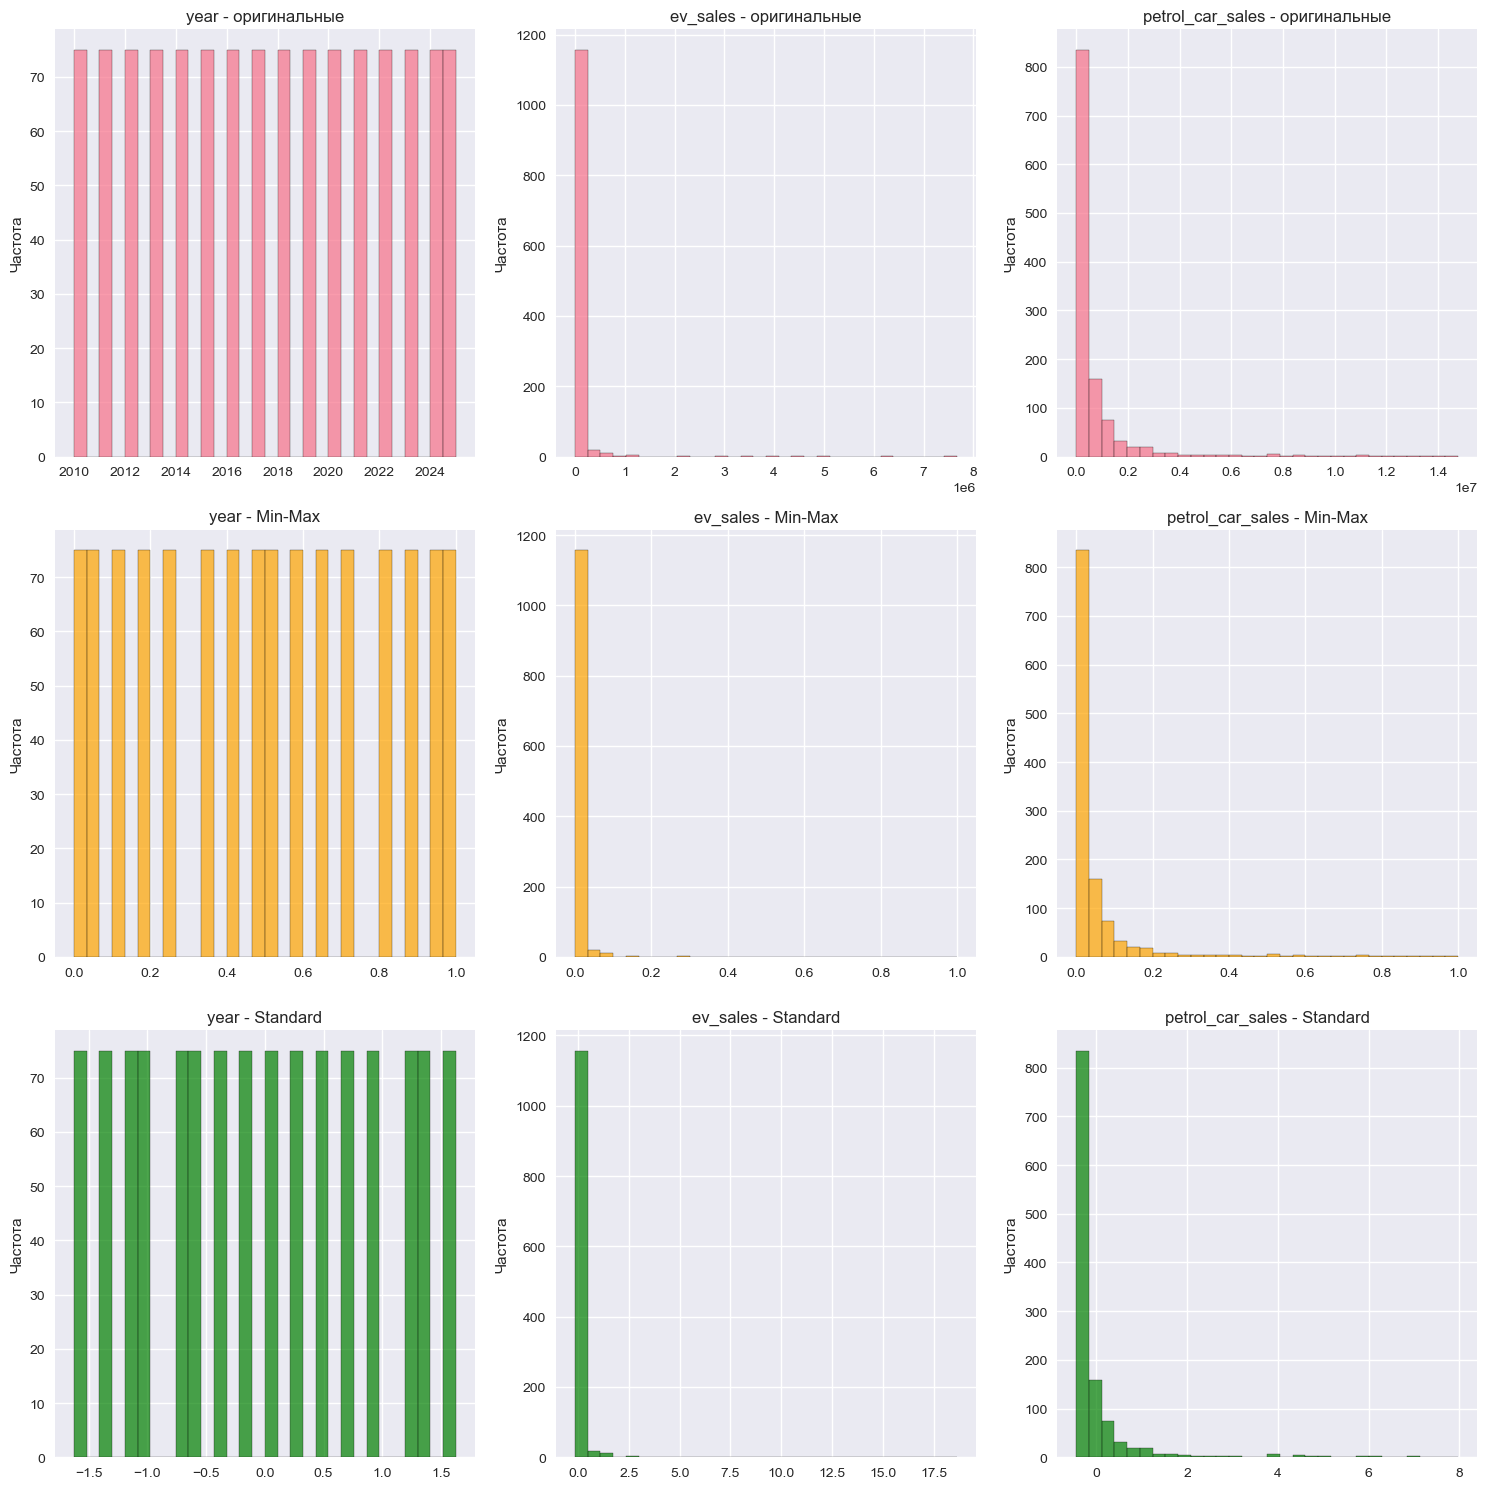

In [14]:
# Сравним статистику после разных методов нормализации
print("Статистика после Min-Max нормализации:")
print(df_minmax_scaled[numerical_features].describe().round(3))

print("\nСтатистика после Standard нормализации:")
print(df_standard_scaled[numerical_features].describe().round(3))

# Визуализация влияния нормализации
sample_features = numerical_features[
    : min(3, len(numerical_features))
]  # Возьмем первые 3 признака для визуализации

fig, axes = plt.subplots(
    3, len(sample_features), figsize=(5 * len(sample_features), 15)
)

# Если только один признак, reshape для корректной работы
if len(sample_features) == 1:
    axes = axes.reshape(-1, 1)
elif len(sample_features) == 1:
    axes = np.array(axes).reshape(3, 1)

for i, feature in enumerate(sample_features):
    # Оригинальные значения
    axes[0, i].hist(df_final_encoded[feature], bins=30, edgecolor="black", alpha=0.7)
    axes[0, i].set_title(f"{feature} - оригинальные")
    axes[0, i].set_ylabel("Частота")

    # Min-Max нормализованные
    axes[1, i].hist(
        df_minmax_scaled[feature], bins=30, edgecolor="black", alpha=0.7, color="orange"
    )
    axes[1, i].set_title(f"{feature} - Min-Max")
    axes[1, i].set_ylabel("Частота")

    # Standard нормализованные
    axes[2, i].hist(
        df_standard_scaled[feature],
        bins=30,
        edgecolor="black",
        alpha=0.7,
        color="green",
    )
    axes[2, i].set_title(f"{feature} - Standard")
    axes[2, i].set_ylabel("Частота")

plt.tight_layout()
plt.show()

## 3.3. Сравнение влияния разных методов нормализации на расстояния


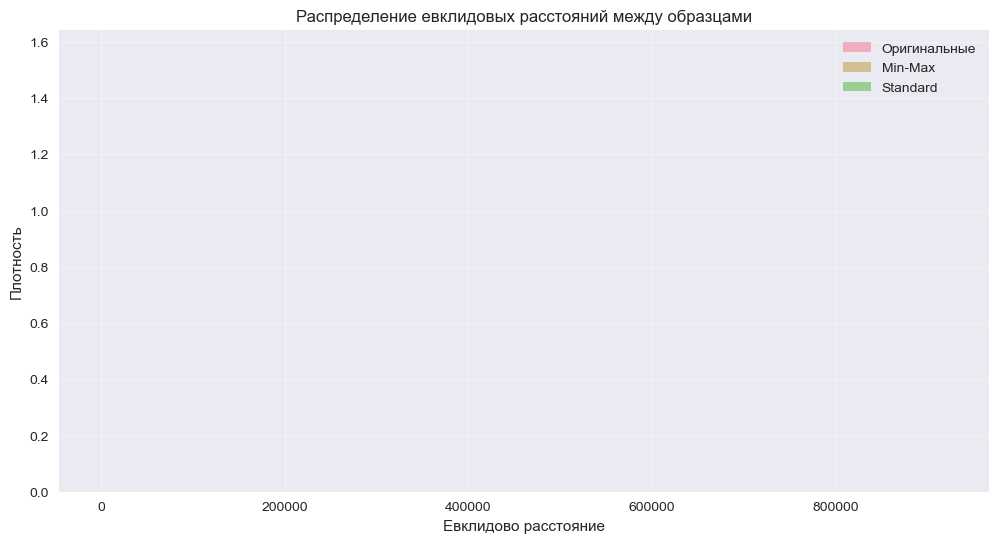

In [15]:
# Рассчитаем евклидовы расстояния между первыми 100 образцами для разных методов
from scipy.spatial.distance import pdist, squareform

# Возьмем подмножество данных для демонстрации
subset_size = min(100, len(df_final_encoded))
original_subset = df_final_encoded[numerical_features][:subset_size]
minmax_subset = df_minmax_scaled[numerical_features][:subset_size]
standard_subset = df_standard_scaled[numerical_features][:subset_size]

# Рассчитаем расстояния
orig_distances = pdist(original_subset.values)
minmax_distances = pdist(minmax_subset.values)
standard_distances = pdist(standard_subset.values)

# Визуализация распределения расстояний
plt.figure(figsize=(12, 6))
plt.hist(orig_distances, bins=50, alpha=0.5, label="Оригинальные", density=True)
plt.hist(minmax_distances, bins=50, alpha=0.5, label="Min-Max", density=True)
plt.hist(standard_distances, bins=50, alpha=0.5, label="Standard", density=True)
plt.xlabel("Евклидово расстояние")
plt.ylabel("Плотность")
plt.title("Распределение евклидовых расстояний между образцами")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

## 3.4. Обоснование выбора оптимального метода


### Выводы по нормализации числовых признаков:

1. **Min-Max Scaling**:
   - Преимущества: Сохраняет все свойства распределения, приводит все признаки к одинаковому диапазону [0,1]
   - Недостатки: Чувствителен к выбросам, так как использует минимум и максимум
   - Использование: Когда известны границы значений признаков, для нейронных сетей

2. **Standardization (Z-score)**:
   - Преимущества: Не чувствителен к выбросам, сохраняет форму распределения
   - Недостатки: Не приводит признаки к одинаковому диапазону
   - Использование: Когда неизвестны границы значений, для большинства алгоритмов машинного обучения

Для этого датасета, содержащего экономические и социальные показатели, более подходящим является **StandardScaler**, так как он более устойчив к выбросам, которые часто встречаются в таких данных.


In [16]:
# Финальная нормализация числовых признаков
df_final_processed = df_final_encoded.copy()
scaler_final = StandardScaler()
df_final_processed[numerical_features] = scaler_final.fit_transform(
    df_final_encoded[numerical_features]
)

print("Финальная статистика обработанных признаков:")
print(df_final_processed[numerical_features].describe().round(3))

print(f"\nФинальный размер датасета: {df_final_processed.shape}")
print(f"Количество обработанных числовых признаков: {len(numerical_features)}")

# Показать список всех столбцов
print(f"\nСписок всех столбцов в финальном датасете:")
print(df_final_processed.columns.tolist())

Финальная статистика обработанных признаков:
           year  ev_sales  petrol_car_sales  diesel_car_sales  \
count  1200.000  1200.000          1200.000          1200.000   
mean      0.000    -0.000             0.000             0.000   
std       1.000     1.000             1.000             1.000   
min      -1.627    -0.156            -0.439            -0.483   
25%      -0.813    -0.155            -0.390            -0.417   
50%       0.000    -0.149            -0.310            -0.308   
75%       0.813    -0.107            -0.077            -0.102   
max       1.627    18.653             7.972             6.434   

       total_vehicle_sales  ev_market_share  charging_stations  \
count             1200.000         1200.000           1200.000   
mean                 0.000            0.000             -0.000   
std                  1.000            1.000              1.000   
min                 -0.434           -0.478             -0.170   
25%                 -0.383           -0

# Заключение


## Выполненные задачи:

1. **Устранение пропусков в данных**:
   - Проанализированы пропуски в данных датасета по электромобилям
   - Применены различные методы заполнения пропусков: среднее, медиана, мода, KNN-импутация
   - В данном случае датасет оказался полным (без пропусков), что подтверждает его хорошую подготовленность

2. **Кодирование категориальных признаков**:
   - Изучены и применены методы Label Encoding и One-Hot Encoding
   - Выбран метод One-Hot Encoding для кодирования категориальных признаков, так как он не вносит искусственный порядок

3. **Нормализация числовых признаков**:
   - Применены методы Min-Max Scaling и Standardization
   - Выбран метод StandardScaler (Z-score нормализация) как более устойчивый к выбросам

## Результаты:

- Исходный датасет с данными о продажах электромобилей и традиционных автомобилей был полностью обработан
- Все признаки приведены к числовому формату и масштабированы
- Получен финальный датасет, готовый для использования в моделях машинного обучения

## Особенности работы с данными о транспорте и окружающей среде:

- Данные охватывают широкий спектр показателей: экономические, социальные, экологические
- Важно учитывать корреляции между признаками (например, между уровнем дохода и покупкой электромобилей)
- Особое внимание к интерпретируемости результатов для принятия политических решений

## Рекомендации:

- При работе с социально-экономическими данными всегда учитывать контекст и взаимосвязи между признаками
- Выбирать методы обработки признаков с учетом специфики данных
- Проверять влияние нормализации на качество прогнозных моделей
